# 🏦 Loan Approval Predictor

Complete ML notebook for the Streamlit loan approval application.

## 1. Import Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load Dataset

In [36]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 3. Clean Columns and Text Values

In [37]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

print(df.columns.tolist())
print("\nLoan status:", df["loan_status"].unique())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

Loan status: ['Approved' 'Rejected']


## 4. Basic Checks

In [38]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (4269, 13)

Missing values:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Duplicates: 0


## 5. Target Distribution

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


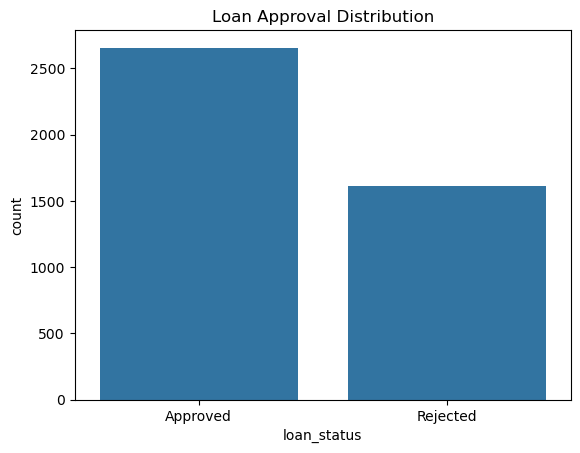

In [39]:
print(df["loan_status"].value_counts())

sns.countplot(data=df, x="loan_status")
plt.title("Loan Approval Distribution")
plt.show()

## 6. Simple EDA

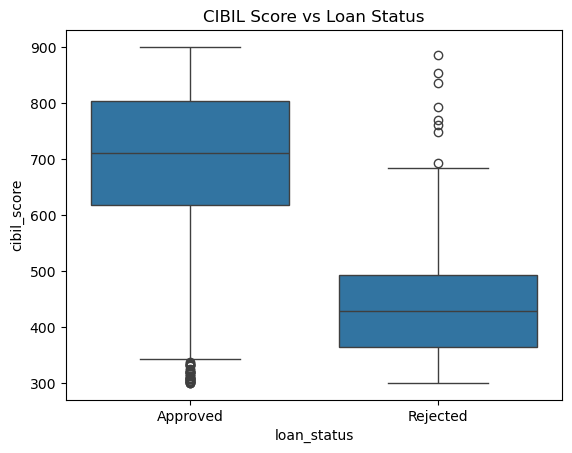

In [40]:
sns.boxplot(data=df, x="loan_status", y="cibil_score")
plt.title("CIBIL Score vs Loan Status")
plt.show()

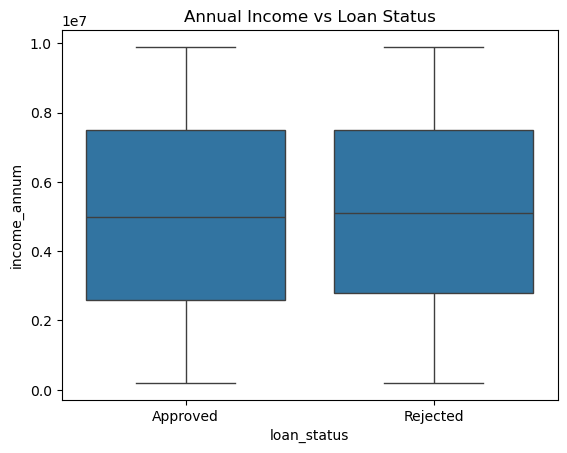

In [41]:
sns.boxplot(data=df, x="loan_status", y="income_annum")
plt.title("Annual Income vs Loan Status")
plt.show()

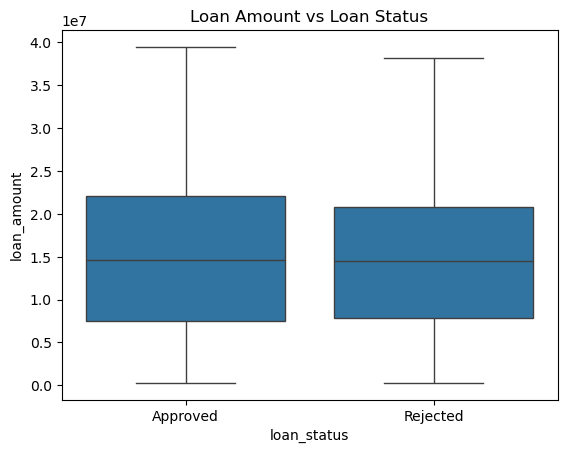

In [42]:
sns.boxplot(data=df, x="loan_status", y="loan_amount")
plt.title("Loan Amount vs Loan Status")
plt.show()

## 7. Remove Loan ID

In [43]:
df = df.drop(columns=["loan_id"])

## 8. Features and Target

In [44]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

print("Features:", X.columns.tolist())
print("Target classes:", y.unique())

Features: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Target classes: ['Approved' 'Rejected']


## 9. Train-Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(3415, 11) (854, 11)


## 10. Numerical and Categorical Features

In [46]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:", numerical_columns)
print("Categorical:", categorical_columns)

Numerical: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical: ['education', 'self_employed']


## 11. Preprocessing

In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

## 12. Logistic Regression Pipeline

In [48]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Model trained.")
print("Classes:", model.classes_)

Model trained.
Classes: ['Approved' 'Rejected']


## 13. Model Evaluation

In [49]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print()
print(classification_report(y_test, y_pred))

Accuracy: 92.27 %

              precision    recall  f1-score   support

    Approved       0.93      0.95      0.94       531
    Rejected       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854



## 14. Confusion Matrix

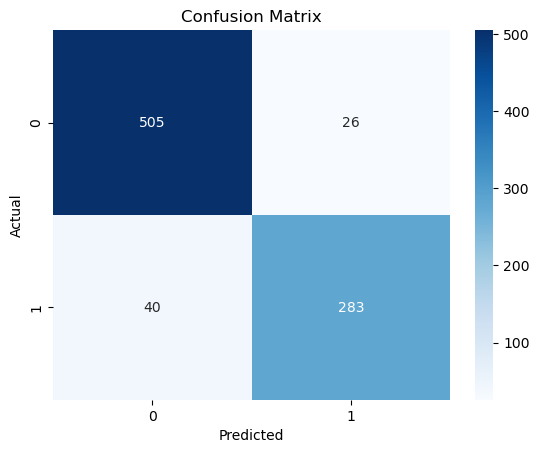

In [50]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 15. Save Training Ranges

In [51]:
training_ranges = {}

for col in numerical_columns:
    training_ranges[col] = {
        "min": float(X_train[col].min()),
        "max": float(X_train[col].max())
    }

training_ranges

{'no_of_dependents': {'min': 0.0, 'max': 5.0},
 'income_annum': {'min': 200000.0, 'max': 9900000.0},
 'loan_amount': {'min': 300000.0, 'max': 39500000.0},
 'loan_term': {'min': 2.0, 'max': 20.0},
 'cibil_score': {'min': 300.0, 'max': 900.0},
 'residential_assets_value': {'min': -100000.0, 'max': 28700000.0},
 'commercial_assets_value': {'min': 0.0, 'max': 19400000.0},
 'luxury_assets_value': {'min': 300000.0, 'max': 39200000.0},
 'bank_asset_value': {'min': 0.0, 'max': 14700000.0}}

## 16. Test New Applicant

In [52]:
candidate = pd.DataFrame({
    "no_of_dependents": [2],
    "education": ["Graduate"],
    "self_employed": ["No"],
    "income_annum": [5000000],
    "loan_amount": [3000000],
    "loan_term": [120],
    "cibil_score": [750],
    "residential_assets_value": [5000000],
    "commercial_assets_value": [2000000],
    "luxury_assets_value": [1000000],
    "bank_asset_value": [2000000]
})

prediction = str(model.predict(candidate)[0]).strip()
probs = model.predict_proba(candidate)[0]

probability_dict = {
    str(cls).strip(): float(prob)
    for cls, prob in zip(model.classes_, probs)
}

print("Prediction:", prediction)
print("Approval:", round(probability_dict.get("Approved", 0) * 100, 2), "%")
print("Rejection:", round(probability_dict.get("Rejected", 0) * 100, 2), "%")

Prediction: Rejected
Approval: 0.0 %
Rejection: 100.0 %


## 17. Save Model

In [53]:
model_package = {
    "model": model,
    "training_ranges": training_ranges,
    "feature_columns": X.columns.tolist()
}

with open("loan_model.pkl", "wb") as file:
    pickle.dump(model_package, file)

print("✅ loan_model.pkl saved successfully.")

✅ loan_model.pkl saved successfully.


## 18. Verify Model

In [54]:
with open("loan_model.pkl", "rb") as file:
    saved = pickle.load(file)

print("Saved keys:", saved.keys())
print("Classes:", saved["model"].classes_)

Saved keys: dict_keys(['model', 'training_ranges', 'feature_columns'])
Classes: ['Approved' 'Rejected']
